In [21]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from main_funcs import *
from pathlib import Path
import numpy as np

In [43]:
base_dirs = {
    "Without": Path("data/Without EDM"),
    "With": Path("data/With EDM"),
    "Without New": Path("data/Without EDM NEW"),
    "With New": Path("data/With EDM NEW")
}

data_all = load_array_data(base_dirs)

In [44]:
# use any run (all runs share the same grids)
run_id = next(iter(data_all["With"]))
X = data_all["With"][run_id]["X"]   # (500,500)
Y = data_all["With"][run_id]["Y"]   # (500,500) mrad

lam_axis = X[0, :]      # (500,)
theta_axis = Y[:, 0]    # (500,)

In [53]:
folder = "Weight_Maps2/"

lam_targets = []
w_slices = []

for filename in os.listdir(folder):
    if not filename.endswith(".npz"):
        continue

    npz = np.load(os.path.join(folder, filename), allow_pickle=True)

    # lambda value
    if "lam" in npz.files:
        lam_k = float(npz["lam"])
    else:
        raise RuntimeError(f"No lam stored in {filename}")

    W_k = npz["weight"]  # expected (500,500)

    # extract the active lambda column
    col_strength = np.sum(np.abs(W_k), axis=0)
    j = int(np.argmax(col_strength))
    w_k = W_k[:, j]      # (500,)

    w_k = weight_per_lam(lam_k, data_all,w0=np.ones_like(theta_axis))

    lam_targets.append(lam_k)
    w_slices.append(w_k)

lam_targets = np.array(lam_targets)
w_slices = np.stack(w_slices, axis=0)   # (n_lam, 500)

In [ ]:
order = np.argsort(lam_targets)
lam_targets = lam_targets[order]
w_slices = w_slices[order]
W_full = np.empty((len(theta_axis), len(lam_axis)), dtype=float)

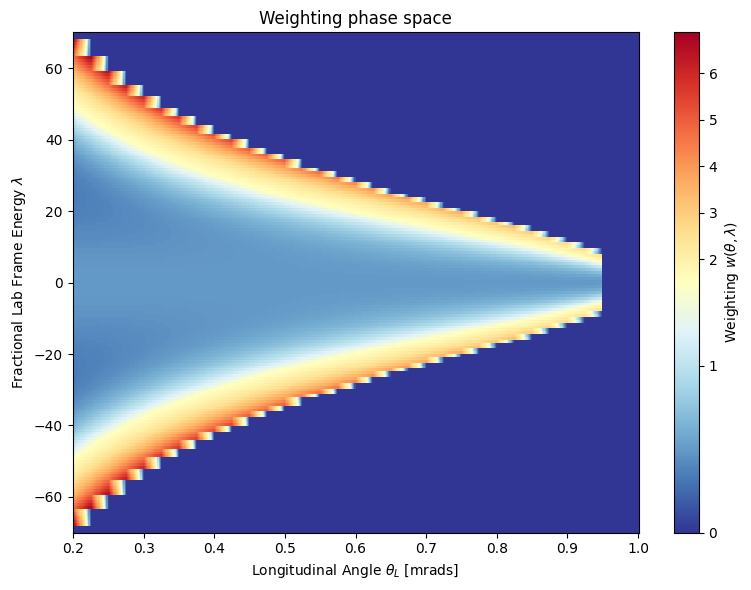

In [55]:
for i in range(len(theta_axis)):
    W_full[i, :] = np.interp(
        lam_axis,
        lam_targets,
        w_slices[:, i],
        left=0,
        right=0,
)
    
cmap = plt.get_cmap("RdYlBu_r")
norm = mcolors.TwoSlopeNorm(
    vmin=W_full.min(),
    vcenter=1.5,   # physics-dominant region
    vmax=W_full.max()
)
    
fig2, ax2 = plt.subplots(figsize=(8, 6))
c = ax2.pcolormesh(X, Y, W_full, shading="auto",cmap=cmap, norm=norm, rasterized=True)
ax2.set_ylabel(r"Fractional Lab Frame Energy $\lambda$")
ax2.set_xlabel(r"Longitudinal Angle $\theta_L$ [mrads]")
ax2.set_title("Weighting phase space")
ax2.set_ylim([-70,70])
fig2.colorbar(c, ax=ax2, label=r"Weighting $w(\theta,\lambda)$")
fig2.tight_layout()
plt.show()

In [ ]:
np.savez_compressed(
    "smoothed_interpolated.npz",
    weight=W_full,
    lam_axis=lam_axis,
    theta_axis=theta_axis,
)

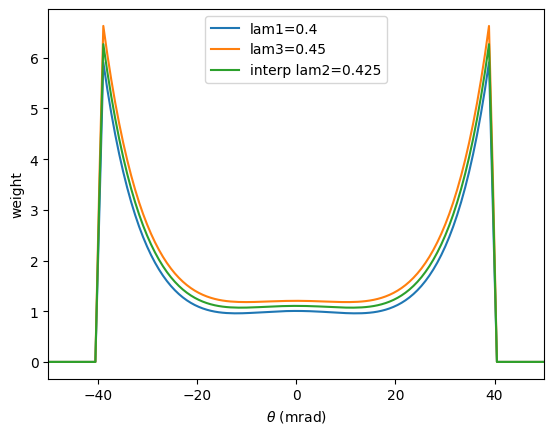

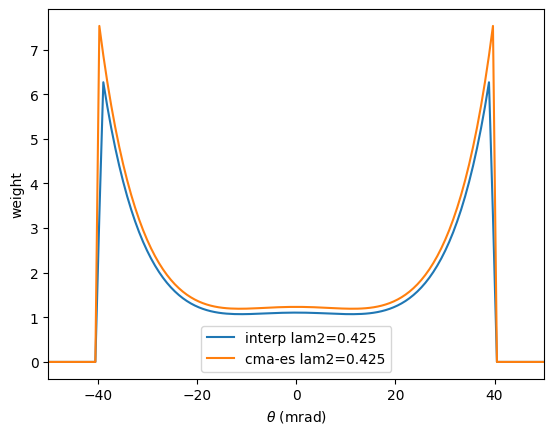

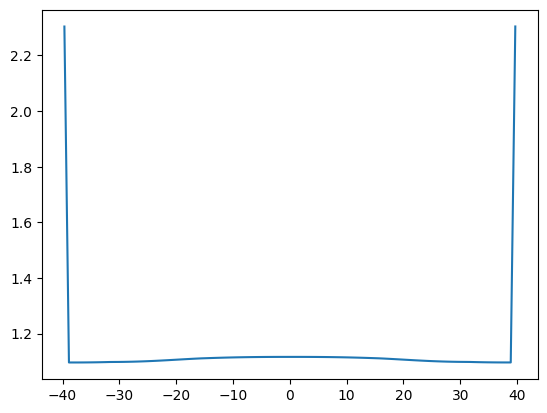

In [86]:
w_450 = np.load("C:/Users/JakeS/Documents/Masters Project/mphys-masters-project/Weight_Maps2/optimal_weight_lam=0.45_budget=2040.npz", allow_pickle=True)["weight"][:,np.argmin(np.abs(lam_axis - 0.450))]
w_425 = np.load("C:/Users/JakeS/Documents/Masters Project/mphys-masters-project/Weight_Maps2/optimal_weight_lam=0.425_budget=2540.npz", allow_pickle=True)["weight"][:,np.argmin(np.abs(lam_axis - 0.425))]
w_400 = np.load("C:/Users/JakeS/Documents/Masters Project/mphys-masters-project/Weight_Maps2/optimal_weight_lam=0.4_budget=2040.npz", allow_pickle=True)["weight"][:,np.argmin(np.abs(lam_axis - 0.400))]

theta = abs(data_all["With"][0]["Y"][:,0])
lam = data_all["With"][0]["X"][0, :]

def theta_max_func(lam,gamma=29.303431969091314):
    return np.asin(np.sqrt(lam*(1-lam))/(gamma*lam))

max_theta = theta_max_func(lam)

# plt.plot(lam,max_theta)
# plt.xlabel(r"$\lambda$")
# plt.ylabel(r"|$\theta_\mathrm{L}$|$_\mathrm{MAX}$")
# plt.show()

lam1 = 0.4
lam2 = 0.425
lam3 = 0.45

theta1 = max_theta[np.argmin(np.abs(X - lam1))]
theta2 = max_theta[np.argmin(np.abs(X - lam2))]
theta3 = max_theta[np.argmin(np.abs(X - lam3))]

s1 = theta2 / theta1
s3 = theta2 / theta3

theta1_scaled = Y[:, 0]*s1
theta3_scaled = Y[:, 0]*s3

#w_k = weight_per_lam(lam_k, data_all,w0=np.ones_like(theta_axis))

w1 = weight_per_lam(lam1, data_all, w_400)
w_425 = weight_per_lam(lam2, data_all, w_425)
w3 = weight_per_lam(lam3, data_all, w_450)

w1_on_theta = np.interp(Y[:,0], theta1_scaled, w1, left=0.0, right=0.0)
w3_on_theta = np.interp(Y[:,0], theta3_scaled, w3, left=0.0, right=0.0)

alpha = (lam2 - lam1) / (lam3 - lam1)
w2_on_theta = (1 - alpha) * w1_on_theta + alpha * w3_on_theta

plt.figure()
plt.plot(Y[:, 0], w1_on_theta, label=f"lam1={lam1:.3g}")
plt.plot(Y[:, 0], w3_on_theta, label=f"lam3={lam3:.3g}")
plt.plot(Y[:, 0], w2_on_theta, label=f"interp lam2={lam2:.3g}")

plt.xlim([-50, 50])
plt.xlabel(r"$\theta$ (mrad)")
plt.ylabel("weight")
plt.legend()
plt.show()

plt.figure()
plt.plot(Y[:, 0], w2_on_theta, label=f"interp lam2={lam2:.3g}")
plt.plot(Y[:, 0], w_425, label=f"cma-es lam2={lam2:.3g}")

plt.xlim([-50, 50])
plt.xlabel(r"$\theta$ (mrad)")
plt.ylabel("weight")
plt.legend()
plt.show()

mask = np.abs(w2_on_theta) > 1e-6

plt.figure()
plt.plot(Y[:, 0][mask], w_425[mask]/w2_on_theta[mask], label=f"interp lam2={lam2:.3g}")
plt.show()

In [97]:
lam_targets = []
w_slices = []

theta_axis = Y[:, 0]      # mrad
lam_axis_1d = X[0, :]     # 1D lambda axis

for filename in os.listdir(folder):
    if not filename.endswith(".npz"):
        continue

    path = os.path.join(folder, filename)
    npz = np.load(path, allow_pickle=True)

    if "lam" in npz.files:
        lam_k = float(npz["lam"])
    else:
        raise RuntimeError(f"No lam stored in {filename}")

    W_k = npz["weight"]

    # choose the column nearest the stored lambda
    j = int(np.argmin(np.abs(lam_axis_1d - lam_k)))
    w_k_raw = W_k[:, j]

    # if you want to post-process the slice, do it here
    # otherwise just use w_k_raw directly
    w_k = weight_per_lam(lam_k, data_all, w0=w_k_raw)

    lam_targets.append(lam_k)
    w_slices.append(w_k)

lam_targets = np.array(lam_targets)
w_slices = np.stack(w_slices, axis=0)   # shape (n_lam_stored, n_theta)

# sort by lambda
order = np.argsort(lam_targets)
lam_targets = lam_targets[order]
w_slices = w_slices[order]

In [98]:
def interp_weight_scaled(lam, lam_targets, w_slices, theta_axis, theta_max_func):
    """
    Interpolate w(theta; lam) by:
      1) finding neighbouring stored lambdas,
      2) rescaling their theta axes to the target theta_max(lam),
      3) interpolating the rescaled curves in lambda.
    """
    # outside range: return zeros
    if lam < lam_targets[0] or lam > lam_targets[-1]:
        return np.zeros_like(theta_axis)

    # exact match: return stored slice directly
    idx_exact = np.where(np.isclose(lam_targets, lam))[0]
    if len(idx_exact) > 0:
        return w_slices[idx_exact[0]].copy()

    # bracketing indices
    j_hi = np.searchsorted(lam_targets, lam)
    j_lo = j_hi - 1

    lam1 = lam_targets[j_lo]
    lam3 = lam_targets[j_hi]

    w1 = w_slices[j_lo]
    w3 = w_slices[j_hi]

    # kinematic max angles
    theta1 = theta_max_func(np.array([lam1]))[0]
    theta2 = theta_max_func(np.array([lam]))[0]
    theta3 = theta_max_func(np.array([lam3]))[0]

    # if theta_max_func returns radians while theta_axis is mrad,
    # convert to mrad here:
    theta1 *= 1000.0
    theta2 *= 1000.0
    theta3 *= 1000.0

    s1 = theta2 / theta1
    s3 = theta2 / theta3

    theta1_scaled = theta_axis * s1
    theta3_scaled = theta_axis * s3

    # interpolate neighbouring slices onto target theta axis
    w1_on_theta2 = np.interp(theta_axis, theta1_scaled, w1, left=0.0, right=0.0)
    w3_on_theta2 = np.interp(theta_axis, theta3_scaled, w3, left=0.0, right=0.0)

    # lambda interpolation
    alpha = (lam - lam1) / (lam3 - lam1)
    w2 = (1.0 - alpha) * w1_on_theta2 + alpha * w3_on_theta2

    return w2

In [99]:
W_full = np.empty((len(theta_axis), len(lam_axis_1d)), dtype=float)

for j, lam in enumerate(lam_axis_1d):
    W_full[:, j] = interp_weight_scaled(
        lam,
        lam_targets,
        w_slices,
        theta_axis,
        theta_max_func
    )

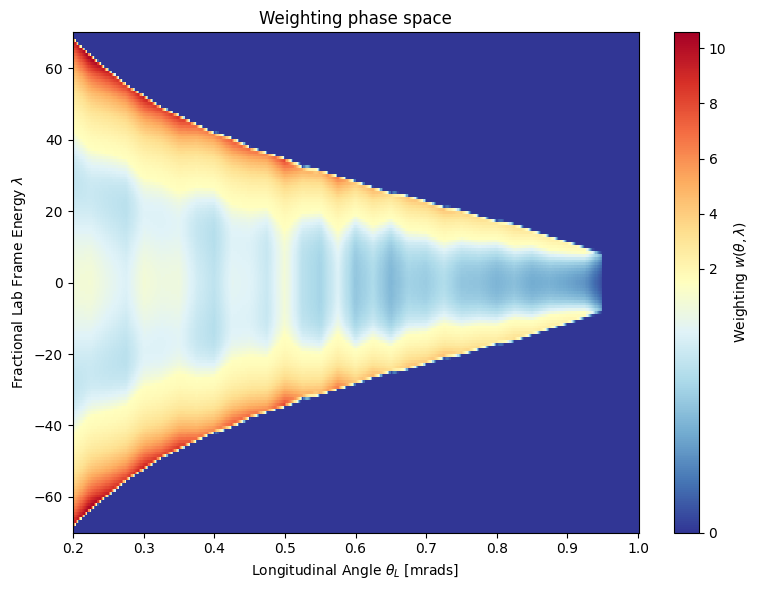

In [100]:
cmap = plt.get_cmap("RdYlBu_r")
norm = mcolors.TwoSlopeNorm(
    vmin=W_full.min(),
    vcenter=1.5,   # physics-dominant region
    vmax=W_full.max()
)
    
fig2, ax2 = plt.subplots(figsize=(8, 6))
c = ax2.pcolormesh(X, Y, W_full, shading="auto",cmap=cmap, norm=norm, rasterized=True)
ax2.set_ylabel(r"Fractional Lab Frame Energy $\lambda$")
ax2.set_xlabel(r"Longitudinal Angle $\theta_L$ [mrads]")
ax2.set_title("Weighting phase space")
ax2.set_ylim([-70,70])
fig2.colorbar(c, ax=ax2, label=r"Weighting $w(\theta,\lambda)$")
fig2.tight_layout()
plt.show()

In [102]:
np.savez_compressed(
    "smoothed_interpolated_rescaled.npz",
    weight=W_full,
    lam_axis=lam_axis,
    theta_axis=theta_axis,
)